# Package

In [1]:
import numpy as np
import pandas as pd
from matplotlib.pyplot import subplots
import statsmodels.formula.api as smf
import statsmodels.api as sm
from ISLP import load_data
from ISLP import confusion_table
from ISLP.models import contrast
from ISLP.models import (ModelSpec as MS)
from sklearn.discriminant_analysis import (LinearDiscriminantAnalysis as LDA, QuadraticDiscriminantAnalysis as QDA)
from sklearn.naive_bayes import GaussianNB
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

# Dataset

In [2]:
Smarket = load_data('Smarket')
Smarket.head()

,Year,Lag1,Lag2,Lag3,Lag4,Lag5,Volume,Today,Direction
0,2001,0.381,-0.192,-2.624,-1.055,5.010,1.1913,0.959,Up
1,2001,0.959,0.381,-0.192,-2.624,-1.055,1.2965,1.032,Up
2,2001,1.032,0.959,0.381,-0.192,-2.624,1.4112,-0.623,Down
3,2001,-0.623,1.032,0.959,0.381,-0.192,1.2760,0.614,Up
4,2001,0.614,-0.623,1.032,0.959,0.381,1.2057,0.213,Up


In [3]:
Smarket.drop("Direction", axis=1).corr()

,Year,Lag1,Lag2,Lag3,Lag4,Lag5,Volume,Today
Year,1.000000,0.029700,0.030596,0.033195,0.035689,0.029788,0.539006,0.030095
Lag1,0.029700,1.000000,-0.026294,-0.010803,-0.002986,-0.005675,0.040910,-0.026155
Lag2,0.030596,-0.026294,1.000000,-0.025897,-0.010854,-0.003558,-0.043383,-0.010250
Lag3,0.033195,-0.010803,-0.025897,1.000000,-0.024051,-0.018808,-0.041824,-0.002448
Lag4,0.035689,-0.002986,-0.010854,-0.024051,1.000000,-0.027084,-0.048414,-0.006900
Lag5,0.029788,-0.005675,-0.003558,-0.018808,-0.027084,1.000000,-0.022002,-0.034860
Volume,0.539006,0.040910,-0.043383,-0.041824,-0.048414,-0.022002,1.000000,0.014592
Today,0.030095,-0.026155,-0.010250,-0.002448,-0.006900,-0.034860,0.014592,1.000000


C'est un dataset en Finance en fait de marché : 
- Lags : rendement dans les jours précédents ; 
- Direction : montée ou descente du marché ; 

<Axes: >

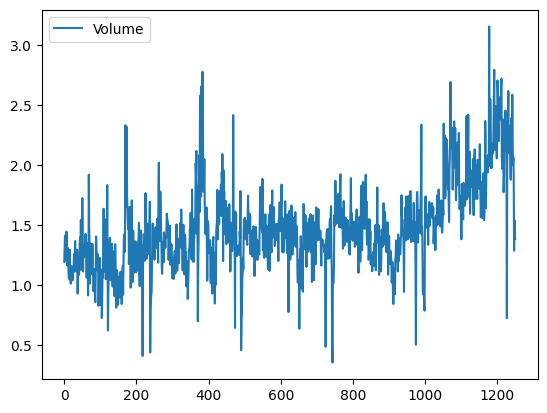

In [4]:
Smarket.plot(y = 'Volume')

# Logistic regression

In [5]:
Smarket.columns

Index(['Year', 'Lag1', 'Lag2', 'Lag3', 'Lag4', 'Lag5', 'Volume', 'Today',
       'Direction'],
      dtype='object')

In [6]:
glm = smf.glm(
    formula = '(Direction == "Up") ~ Lag1 + Lag2 + Lag3 + Lag3 + Lag4 + Lag5 + Volume', 
    data=Smarket, 
    family = sm.families.Binomial()
    ).fit()
print(glm.summary())

                                    Generalized Linear Model Regression Results                                    
Dep. Variable:     ['Direction == "Up"[False]', 'Direction == "Up"[True]']   No. Observations:                 1250
Model:                                                                 GLM   Df Residuals:                     1243
Model Family:                                                     Binomial   Df Model:                            6
Link Function:                                                       Logit   Scale:                          1.0000
Method:                                                               IRLS   Log-Likelihood:                -863.79
Date:                                                     Wed, 18 Feb 2026   Deviance:                       1727.6
Time:                                                             12:36:55   Pearson chi2:                 1.25e+03
No. Iterations:                                                         

In [7]:
print(glm.params)
print(glm.pvalues)

Intercept    0.126000
Lag1         0.073074
Lag2         0.042301
Lag3        -0.011085
Lag4        -0.009359
Lag5        -0.010313
Volume      -0.135441
dtype: float64
Intercept    0.600700
Lag1         0.145232
Lag2         0.398352
Lag3         0.824334
Lag4         0.851445
Lag5         0.834998
Volume       0.392404
dtype: float64


In [8]:
# C'est la probabilité d'avoir une classe 0,1
probs = glm.predict()
probs[:10]

array([0.49291587, 0.51853212, 0.51886117, 0.48477764, 0.48921884,
       0.49304354, 0.50734913, 0.49077084, 0.48238647, 0.51116222])

In [9]:
print(np.mean(probs))
print(np.std(probs))
print(np.min(probs))
print(np.max(probs))

0.4816
0.026745763346708112
0.35135649244795564
0.5915538914037954


In [10]:
# Confusion matrix 
labels = np.array(['Down'] * 1250)
labels[probs > 0.5] = "Up"
confusion_table(labels, Smarket.Direction)

Truth,Down,Up
Predicted,,
Down,457,507
Up,145,141


In [11]:
(507+145)/1250, np.mean(labels == Smarket.Direction)

(0.5216, np.float64(0.4784))

# Split Data

In [12]:
train = (Smarket.Year < 2005)
Smarket_train = Smarket.loc[train]
Smarket_test = Smarket.loc[~train]
Smarket_test.shape

(252, 9)

# Logistic regression

In [13]:
allvars = Smarket.columns[1:3]
design = MS(allvars)
X = design.fit_transform(Smarket)

In [15]:
X_train, X_test = X.loc[train], X.loc[~train]
y_train, y_test = y.loc[train], y.loc[~train]
glm_train = sm.GLM(y_train,
                   X_train,
                   family=sm.families.Binomial())
glm_train = glm_train.fit()
probs = glm_train.predict(exog= X_test)

In [54]:
y_train

0       True
1       True
2      False
3       True
4       True
       ...  
993    False
994     True
995    False
996     True
997    False
Name: Direction, Length: 998, dtype: bool

In [16]:
D = Smarket.Direction
L_train, L_test = D.loc[train], D.loc[~train]

In [17]:
labels = np.array(['Down']*252)
labels[probs>0.5] = 'Up'
confusion_table(labels, L_test)

Truth,Down,Up
Predicted,,
Down,35,35
Up,76,106


In [18]:
(35+106)/252,106/(106+76)

(0.5595238095238095, 0.5824175824175825)

La précision est de 56% tandis que le taux d'erreur est de 58%. 

In [19]:
newdata = pd.DataFrame({'Lag1':[1.2, 1.5],'Lag2':[1.1,-0.8]})
newX = design.transform(newdata)
glm_train.predict(newX)

0    0.479146
1    0.496094
dtype: float64

# LDA

In [20]:
lda = LDA(store_covariance=True)

In [21]:
# On change directement X_train et X_test via la variable M
X_train, X_test = [M.drop(columns=['intercept'])
                   for M in [X_train, X_test]]
lda.fit(X_train, L_train)

,solver,'svd'
,shrinkage,None
,priors,None
,n_components,None
,store_covariance,True
,tol,0.0001
,covariance_estimator,None


In [22]:
# çà renvoit la moyenne de Lag1 et Lag2 par classe Down et Classe Up.
# Voilà pourquoi on a une matrice de 02 lignes et 02 colonnes. 
lda.means_

array([[ 0.04279022,  0.03389409],
       [-0.03954635, -0.03132544]])

In [23]:
# Les classes dans le modèle
lda.classes_

array(['Down', 'Up'], dtype='<U4')

In [24]:
# Pobabilité au hasard d'appartenir dans une classe
lda.priors_

array([0.49198397, 0.50801603])

In [25]:
# Ce sont les coefficients
lda.scalings_

array([[-0.64201904],
       [-0.51352928]])

In [26]:
# Prédiction des classes
lda_pred = lda.predict(X_test)

In [27]:
# LDA prédit la même chose que la régression logistique
confusion_table(lda_pred, L_test)

Truth,Down,Up
Predicted,,
Down,35,35
Up,76,106


In [28]:
# Probabilité d'appartenir dans une ou autre classe et comment c'est fait le choix
lda_prob = lda.predict_proba(X_test)
np.all(

    np.where(lda_prob[:, 1] >= 0.5, 'Up', 'Down') == lda_pred
)

np.True_

## Explication du code 
- La première ligne envoie la probabilité d'appartenir dans les classes. Celà renvoie deux colonnes deux probabilités. P(Y=0∣X) et P(Y=1∣X)
- La troisième ligne signifie que si la probabilité dans la deuxième colonne P(Y=1∣X)=1 est supérieur à 0.5, alors le modèle LDA classe l'observation en 'Up'. Sinon, il classe en 'Down'
- En effet, si A est un numpy à 2 dimensions, voici comment on sélectionne : 

A[i, j] avec 

i : ligne ; 
j : colonne ; 

In [29]:
# Avec une dimension, le code suivant me sort l'indice de la plus grande valeur 
np.argmax([1,2,3,5])

np.int64(3)

In [30]:
# Avec deux dimensions, le code suivant me sort l'indice de la plus grande valeur 
A = np.array([[1,2], 
     [2,1],
     [7,9]])
print(A.shape)
print(np.argmax(A, 1))
# avec une matrice de 03 lignes et 02 colonnes
# l'argmax envoit 
# par ligne 
# l'indice de la colonne de valeur la plus grande par ligne

(3, 2)
[1 0 1]


In [31]:
# Avec deux dimensions, le code suivant me sort l'indice de la plus grande valeur 
A = np.array([[1,2], 
     [2,1],
     [7,9]])
print(A.shape)
print(np.argmax(A, 0))
# C'est le même raisonnement mais cette fois-ci on envoit l'indice de ligne par colonne

(3, 2)
[2 2]


In [32]:
# Pour le cas de multi-classe
np.all(
[lda.classes_[i] for i in np.argmax(lda_prob, 1)] ==
lda_pred
)

np.True_

In [33]:
# Compter la Probabilité d'appartenir dans la classe 0 (Dump) > 0.9
np.sum(lda_prob[:,0] > 0.9)

np.int64(0)

# QDA

In [34]:
qda = QDA(store_covariance=True)
qda.fit(X_train, L_train)

,priors,None
,reg_param,0.0
,store_covariance,True
,tol,0.0001


In [35]:
qda.means_

array([[ 0.04279022,  0.03389409],
       [-0.03954635, -0.03132544]])

In [36]:
qda.priors_

array([0.49198397, 0.50801603])

In [37]:
qda.covariance_[0]

array([[ 1.50662277, -0.03924806],
       [-0.03924806,  1.53559498]])

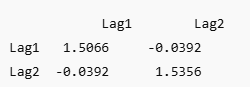

En fait, c'est la matrice de covariance. En diagonale on a la variance et les autres sont les corrélations. 

In [38]:
qda_pred = qda.predict(X_test)
confusion_table(qda_pred, L_test)

Truth,Down,Up
Predicted,,
Down,30,20
Up,81,121


QDA est précis à 60% contrairement aux deux précédents à 50% sans le fit. Parce qu'il capte mieux les relations non-linéaires. 

In [39]:
np.mean(qda_pred == L_test)

np.float64(0.5992063492063492)

# Naive Bayes

In [40]:
NB = GaussianNB()
NB.fit(X_train, L_train)

,priors,None
,var_smoothing,1e-09


In [41]:
NB.classes_

array(['Down', 'Up'], dtype='<U4')

In [42]:
NB.class_prior_

array([0.49198397, 0.50801603])

In [43]:
# Coefficient de la variable par rapport à chaque classe
NB.theta_

array([[ 0.04279022,  0.03389409],
       [-0.03954635, -0.03132544]])

In [44]:
NB.var_

array([[1.50355429, 1.53246749],
       [1.51401364, 1.48732877]])

In [45]:
X_train[L_train == 'Down'].mean()

Lag1    0.042790
Lag2    0.033894
dtype: float64

In [46]:
X_train[L_train == 'Down'].var(ddof=0)

Lag1    1.503554
Lag2    1.532467
dtype: float64

In [47]:
nb_labels = NB.predict(X_test)
confusion_table(nb_labels, L_test)

Truth,Down,Up
Predicted,,
Down,29,20
Up,82,121


In [48]:
(29 + 121) / (29+82+20+121)

0.5952380952380952

Mieux que LDA mais et un moins bon que QDA avec une précision de 59%. 

In [49]:
NB.predict_proba(X_test)[:5]

array([[0.4873288 , 0.5126712 ],
       [0.47623584, 0.52376416],
       [0.46529531, 0.53470469],
       [0.47484469, 0.52515531],
       [0.49020587, 0.50979413]])